In [1]:
from xgw.gromov_wasserstein_m_dist import gw_m_convex, classical_gw

# open and convert to grayscale
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt



In [2]:
fname = 'hand.png'
img = Image.open(fname).convert('L')
img_array = np.array(img)
img_array.shape

(228, 455)

# whole hand (inside)

(-0.5, 204.5, 187.5, -0.5)

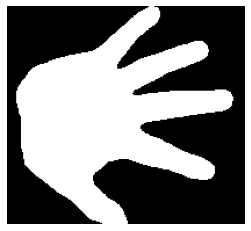

In [4]:
crop = img_array[20:-20, 250:]
# binarize
crop = (crop > 128).astype(float)
plt.imshow(crop, cmap='gray')
plt.axis('off')

In [ ]:
# downsample image
ds_factor = 3
crop = crop[::ds_factor, ::ds_factor]
plt.imshow(crop, cmap='gray')
plt.axis('off')
print(crop.shape)


In [ ]:
import pandas as pd
pd.Series(crop.flatten()).sort_values().plot.hist(bins=50)

In [ ]:
i_mesh, j_mesh = np.meshgrid(np.arange(crop.shape[1], dtype=float), np.arange(crop.shape[0], dtype=float), indexing='ij')
points = np.vstack([i_mesh.flatten(), j_mesh.flatten()]).T
points /= np.max(np.linalg.norm(points, axis=1, keepdims=True))

# i_mesh, j_mesh = np.meshgrid(np.arange(crop.shape[1], dtype=float), np.arange(crop.shape[0], dtype=float), indexing='ij')
# i_mesh *= -1
# points_flipped = np.vstack([i_mesh.flatten(), j_mesh.flatten()]).T
# points_flipped /= np.max(np.linalg.norm(points_flipped, axis=1, keepdims=True))

mu = crop.flatten() / crop.sum()

mu_flipped = crop[::-1].flatten() / crop.sum()

In [ ]:
# plt.imshow(np.arange(100).reshape(10,10))
# plt.colorbar()

In [ ]:
T, plan, c, _, _ = gw_m_convex(mu, points, mu_flipped, points, {'numItermax': 10**9}, cost='CGW', gap_tol=1e-15, iter_max=200, FW_iter=100, p_plus_implementation='cdd') 

In [ ]:
# vertical gradient
binary = crop.astype(bool)
H, W = binary.shape
grad = np.linspace(0, 1, H)[:, None]
grad = np.repeat(grad, W, axis=1)

# convert gradient to colors
cmap = plt.cm.viridis
colors = cmap(grad)[..., :3]

# apply mask
colored = np.ones((H, W, 3))  # white background
colored[binary] = colors[binary]

plt.imshow(colored)
plt.axis("off")
plt.title('Original Image with Gradient Colors')
plt.savefig('hand_original.png', dpi=300, bbox_inches='tight')

In [ ]:
# vertical gradient
binary = crop[::-1].astype(bool)
H, W = binary.shape
grad = np.linspace(0, 1, H)[:, None]
grad = np.repeat(grad, W, axis=1)

# convert gradient to colors
cmap = plt.cm.viridis
colors = cmap(grad)[..., :3][::-1]

# apply mask
colored = np.ones((H, W, 3))  # white background
colored[binary] = colors[binary]

plt.imshow(colored)
plt.title('Perfect Mirror Image')
plt.axis("off")
plt.savefig('hand_perfect_flip.png', dpi=300, bbox_inches='tight')

In [ ]:
perm = plan.argmax(axis=0)
# vertical gradient
binary = crop[::-1].astype(bool)
H, W = binary.shape
grad = np.linspace(0, 1, H)[:, None]
grad = np.repeat(grad, W, axis=1)

# convert gradient to colors
cmap = plt.cm.viridis
colors = cmap(grad)[..., :3][::-1]

# apply mask
colored = np.ones((H, W, 3))  # white background
transported_colors = colors.reshape(-1,3)[perm].reshape(colored.shape)
colored[binary] = transported_colors[binary]

plt.imshow(colored)
plt.axis("off")
plt.title('Chiral GW')
plt.savefig('hand_cgw.png', dpi=300, bbox_inches='tight')

In [ ]:
_, plan_gw, _, _, _ = classical_gw(mu, points, mu_flipped, points, {'numItermax': 10**10},  cost_tol=1e-18, iter_max=300, FW_iter=100, p_plus_implementation='cdd') 

In [ ]:
perm = plan_gw.argmax(axis=0)
# vertical gradient
binary = crop[::-1].astype(bool)
H, W = binary.shape
grad = np.linspace(0, 1, H)[:, None]
grad = np.repeat(grad, W, axis=1)

# convert gradient to colors
cmap = plt.cm.viridis
colors = cmap(grad)[..., :3][::-1]

# apply mask
colored = np.ones((H, W, 3))  # white background
transported_colors = colors.reshape(-1,3)[perm].reshape(colored.shape)
colored[binary] = transported_colors[binary]

plt.imshow(colored)
plt.axis("off")
plt.title('Classical GW')
plt.savefig('hand_gw.png', dpi=300, bbox_inches='tight')

# contours

(-0.5, 204.5, 197.5, -0.5)

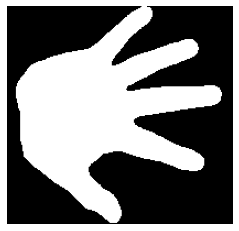

In [3]:
crop = img_array[20:-10, 250:]
# binarize
crop = (crop > 128).astype(float)
plt.imshow(crop, cmap='gray')
plt.axis('off')

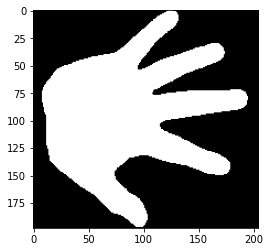

In [4]:
import cv2 as cv
ret, thresh = cv.threshold(crop*128, 127, 255, 0)
thresh = thresh.astype(np.uint8)
plt.imshow(thresh, interpolation=None, cmap='gray')


In [5]:
contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_NONE)     

893

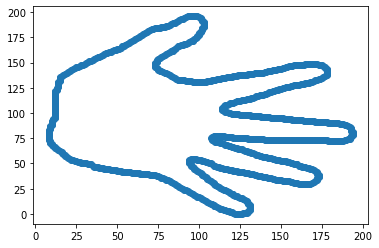

In [6]:
outline = contours[0].reshape(-1, 2)
plt.plot(outline[:,0], outline[:,1], linestyle='-', marker='o')
len(outline)

In [43]:
# poster presets
import seaborn as sns

# Set poster style (larger fonts, thicker lines)
sns.set_context("poster")  # options: "paper", "notebook", "talk", "poster"
sns.set_style("white")

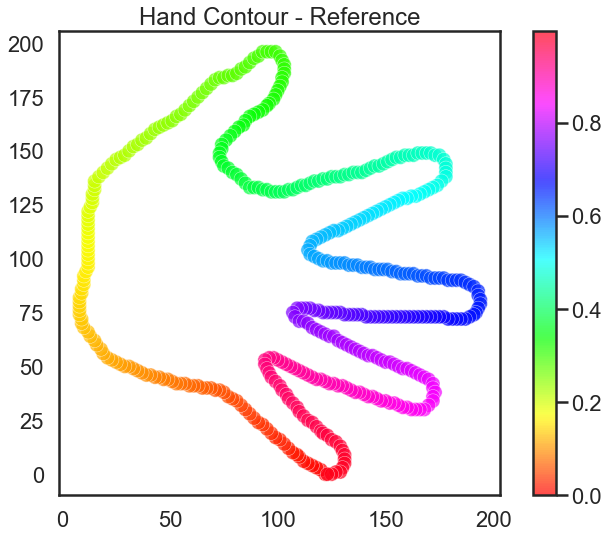

In [51]:
# Color points as rainbow on scatter plot with looping rainbow

# Create looping rainbow colors (wraps around multiple times)
n_skip = 2
points = outline.astype(float)
reduced_points = points[::n_skip]
n_points = len(reduced_points)
n_loops = 1  # number of times to loop through the rainbow
colors_idx = (np.arange(n_points) / n_points * n_loops) % 1.0  # normalized to [0, 1]

# Plot points with looping rainbow colors
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(reduced_points[:, 0], reduced_points[:, 1], 
                     c=colors_idx,  # looping color index
                     cmap='hsv',    # hsv wraps nicely
                     s=200, 
                     alpha=0.7,
                     edgecolors='white',
                     linewidth=0.5)

# Draw connecting lines (order matters for contour)
# ax.plot(points[:, 0], points[:, 1], 'k-', alpha=0.3, linewidth=1)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, )

ax.set_aspect('equal')
ax.set_title('Hand Contour - Reference')
plt.tight_layout()
plt.savefig('hand/hand_contour_reference.svg', dpi=300)


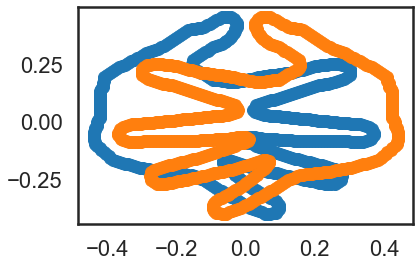

In [56]:
points = outline.astype(float)
points = points[::n_skip]
points /= np.max(np.linalg.norm(points, axis=1, keepdims=True))
points -= points.mean(axis=0, keepdims=True)
points_flipped = points.copy()
points_flipped[:,0] *= -1
mu = np.ones(len(points)) / len(points)
plt.plot(points[:,0], points[:,1], linestyle='-', marker='o')

plt.plot(points_flipped[:,0], points_flipped[:,1], linestyle='-', marker='o')



## CGW

2026-04-06 21:50:45.611 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:50:45.660 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:50:45.703 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:50:45.742 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:50:45.775 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:50:45.779 - Adding new half-planes and vertices to the bounding boxes
2026-04-06 21:50:45.781 - Computing vertices from half-planes: A shape (5, 4), b shape (5,)
2026-04-06 21:50:45.786 - Feasibility check result: True
2026-04-06 21:50:45.793 - Linprog result:        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
       success: True
        status: 0
           fun: 0.0
             x: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
           nit: 0
         lower:  residual: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
                marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
         upper:  residual: [       inf        inf 

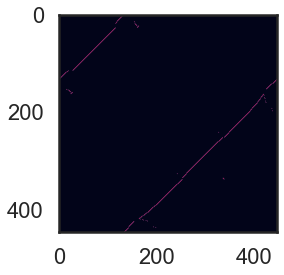

In [61]:
T, plan, c, _, _ = gw_m_convex(mu, points, mu, points_flipped, {'numItermax': 10**9}, cost='CGW', gap_tol=1e-15, iter_max=300, FW_iter=100, 
                               p_plus_implementation='h_to_v_popcount_sparse', 
                               p_minus_implementation='v_to_h_dual',
                               p_minus_dual_implementation='h_to_v_popcount_sparse') 
plt.imshow(plan)

2026-04-06 21:49:27.132 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:49:27.177 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:49:27.237 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:49:27.298 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:49:27.358 - e_base (447, 447, 4), pi (447, 447)
2026-04-06 21:49:27.362 - Adding new half-planes and vertices to the bounding boxes
2026-04-06 21:49:27.365 - Computing vertices from half-planes: A shape (5, 4), b shape (5,)
2026-04-06 21:49:27.368 - Feasibility check result: True
2026-04-06 21:49:27.372 - Linprog result:        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
       success: True
        status: 0
           fun: 0.0
             x: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
           nit: 0
         lower:  residual: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
                marginals: [ 0.000e+00  0.000e+00  0.000e+00  0.000e+00]
         upper:  residual: [       inf        inf 

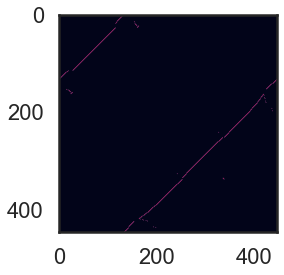

In [59]:
T, plan, c, _, _ = gw_m_convex(mu, points, mu, points_flipped, {'numItermax': 10**9}, cost='CGW', gap_tol=1e-15, iter_max=140, FW_iter=100, 
                               p_plus_implementation='cdd', 
                               p_minus_implementation='cdd',
                               p_minus_dual_implementation=None) 
plt.imshow(plan)

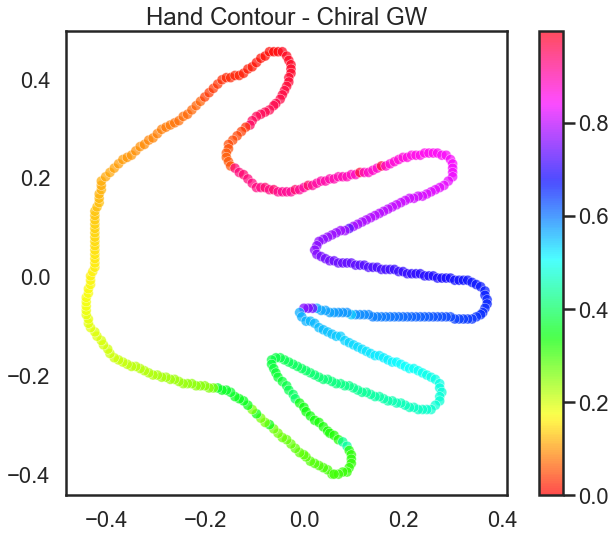

In [62]:
# Color points as rainbow on scatter plot with looping rainbow



# Create looping rainbow colors (wraps around multiple times)
n_points = len(points)
n_loops = 1  # number of times to loop through the rainbow
colors_idx = (np.arange(n_points) / n_points * n_loops) % 1.0  # normalized to [0, 1]
perm = plan.argmax(axis=0)
colors_idx = colors_idx[perm]  # reorder colors according to transport plan

# Plot points with looping rainbow colors
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(points[:, 0], points[:, 1], 
                     c=colors_idx,  # looping color index
                     cmap='hsv',    # hsv wraps nicely
                     s=100, 
                     alpha=0.7,
                     edgecolors='white',
                     linewidth=0.5)

# Draw connecting lines (order matters for contour)
# ax.plot(points[:, 0], points[:, 1], 'k-', alpha=0.3, linewidth=1)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, )

ax.set_aspect('equal')
ax.set_title('Hand Contour - Chiral GW')
plt.tight_layout()
plt.savefig('hand/hand_contour_cgw.svg', dpi=300)

## Classical GW

In [24]:
mu = np.ones(len(reduced_points)) / len(reduced_points)

_, plan_gw, _, _, _ = classical_gw(mu, reduced_points, mu, points_flipped, {'numItermax': 10**10}, cost_tol=1e-18, iter_max=100, FW_iter=100, 
                               p_plus_implementation='cdd', 
                               p_minus_implementation='cdd',
                               ) 

2026-04-06 14:15:59.603 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.624 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.645 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.665 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.684 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.704 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.725 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.746 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.769 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.789 - e_base (298, 298, 5), pi (298, 298)
2026-04-06 14:15:59.791 - Adding new half-planes and vertices to the bounding boxes
2026-04-06 14:15:59.792 - Computing vertices from half-planes: A shape (10, 5), b shape (10,)
2026-04-06 14:15:59.795 - Feasibility check result: False
2026-04-06 14:15:59.796 - Linprog result:        message: The problem is infeasible. (HiGHS Status 8: model_status is Infeasible; primal_status 

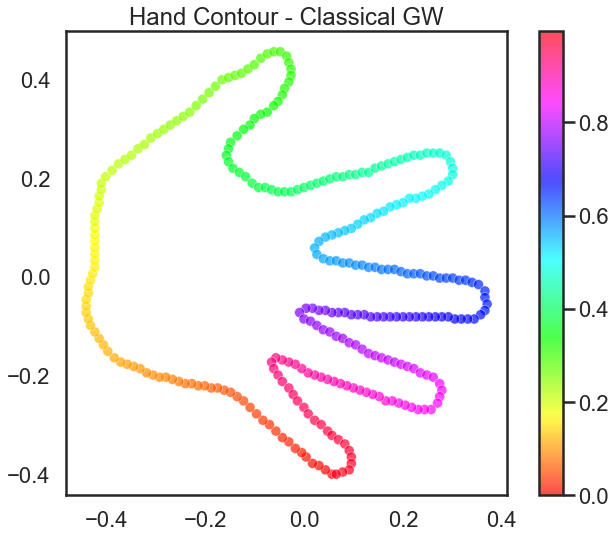

In [48]:
# Color points as rainbow on scatter plot with looping rainbow

# Create looping rainbow colors (wraps around multiple times)
n_points = len(points)
n_loops = 1  # number of times to loop through the rainbow
colors_idx = (np.arange(n_points) / n_points * n_loops) % 1.0  # normalized to [0, 1]
perm = plan_gw.argmax(axis=0)
colors_idx = colors_idx[perm]  # reorder colors according to transport plan

# Plot points with looping rainbow colors
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(points[:, 0], points[:, 1], 
                     c=colors_idx,  # looping color index
                     cmap='hsv',    # hsv wraps nicely
                     s=100, 
                     alpha=0.7,
                     edgecolors='white',
                     linewidth=0.5)

# Draw connecting lines (order matters for contour)
# ax.plot(points[:, 0], points[:, 1], 'k-', alpha=0.3, linewidth=1)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax, )

ax.set_aspect('equal')
ax.set_title('Hand Contour - Classical GW')
plt.tight_layout()
plt.savefig('hand/hand_contour_classicalgw.svg', dpi=300)

In [54]:
np.allclose(plan_gw * len(plan_gw), np.eye(len(plan_gw)))

True